# Price Processes — GBM, Ornstein-Uhlenbeck, Jump Diffusion

Side-by-side comparison of the three synthetic price processes in `market/generators/`:

- **`PriceGenerator`** — Geometric Brownian Motion
- **`OrnsteinUhlenbeckProcess`** — mean-reverting process, exact discrete-time solution
- **`JumpDiffusionProcess`** — Merton jump-diffusion (GBM + compound Poisson jumps)

Each is driven directly through its `price_path()` / `value_path()` method — raw numpy
arrays, no `EventQueue`/`EventLoop` overhead. Same interface across all three, same default
horizon (252 steps, one simulated trading year) and seed, so the paths are directly comparable.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from market_sim.core.clock import SimulationClock
from market_sim.core.config import (
    default_config,
    default_jump_diffusion_config,
    default_ou_config,
)
from market_sim.market import JumpDiffusionProcess, OrnsteinUhlenbeckProcess, PriceGenerator

## Generate paths

Each generator gets a fresh `SimulationClock` since `price_path()` doesn't touch it anyway —
kept here only for constructor-signature parity with `generate()`.

In [2]:
gbm_config = default_config()
ou_config = default_ou_config()
jd_config = default_jump_diffusion_config()

gbm_path = PriceGenerator(config=gbm_config, clock=SimulationClock()).price_path()
ou_path = OrnsteinUhlenbeckProcess(config=ou_config, clock=SimulationClock()).value_path()
jd_path = JumpDiffusionProcess(config=jd_config, clock=SimulationClock()).price_path()

time_axis = np.arange(len(gbm_path)) * gbm_config.dt
print(f"{len(time_axis)} points over {time_axis[-1]:.2f} simulated years")

253 points over 1.00 simulated years


## Side-by-side comparison

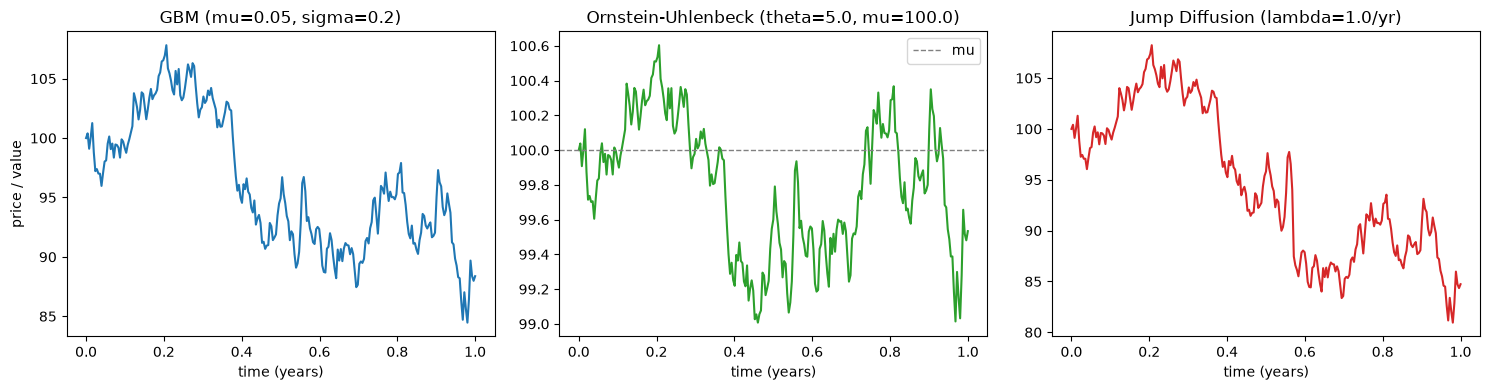

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].plot(time_axis, gbm_path, color="tab:blue")
axes[0].set_title(f"GBM (mu={gbm_config.mu}, sigma={gbm_config.sigma})")

axes[1].plot(time_axis, ou_path, color="tab:green")
axes[1].axhline(ou_config.mu, color="gray", linestyle="--", linewidth=1, label="mu")
axes[1].set_title(f"Ornstein-Uhlenbeck (theta={ou_config.theta}, mu={ou_config.mu})")
axes[1].legend()

axes[2].plot(time_axis, jd_path, color="tab:red")
axes[2].set_title(f"Jump Diffusion (lambda={jd_config.jump_intensity}/yr)")

for ax in axes:
    ax.set_xlabel("time (years)")
axes[0].set_ylabel("price / value")

fig.tight_layout()
plt.show()

## GBM vs. Jump Diffusion, overlaid

`JumpDiffusionProcess` draws its diffusion noise as the *first* RNG call from a freshly seeded
generator — exactly like `PriceGenerator` does. With the same seed, mu, and sigma, that means
the continuous component of both paths is bit-identical (see
`tests/market/test_jump_diffusion.py::test_zero_jump_intensity_matches_pure_gbm`), so overlaying
them isolates exactly what the jumps contribute — nothing else differs between the two lines
below except the compound Poisson jump component.

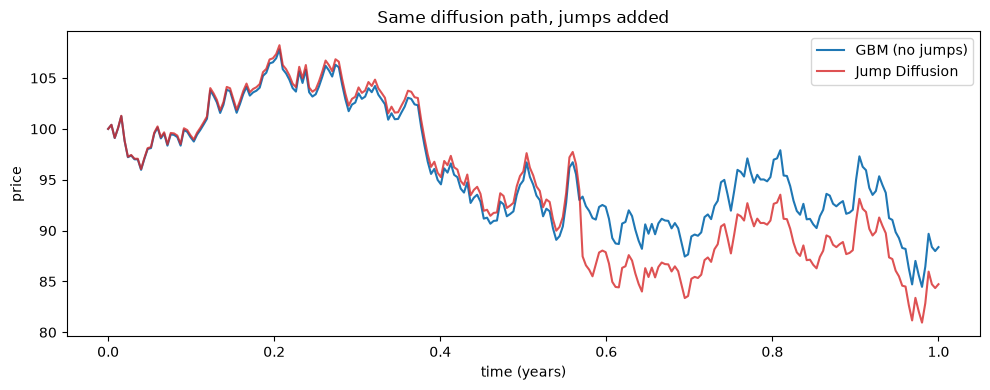

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(time_axis, gbm_path, label="GBM (no jumps)", color="tab:blue")
plt.plot(time_axis, jd_path, label="Jump Diffusion", color="tab:red", alpha=0.8)
plt.xlabel("time (years)")
plt.ylabel("price")
plt.title("Same diffusion path, jumps added")
plt.legend()
plt.tight_layout()
plt.show()